# Dated trees workflow example

In this notebook we will walk through the sequence of steps that generate the dated complete trees. We will illustrate the steps on a small example tree, using a subset of species in the order of electric rays (Torpediniformes).

This small tree is available in the examples folder as `examples/Torpediniformes.tre`, and the associated subsets of the Open Tree Taxonomy and Open Tree annotations are also included in that folder. The tree is extracted from the Open Tree of Life 16.1, but no data downloads outside of this repository are required to follow this notebook.

(At the bottom of the notebook are the steps used to extract the example tree from the full Open Tree of Life, if you would like to see or adapt this code.)

## Prerequisites

You will require the `ete4` and `numpy` packages.

## 1. Package setup

First, let's check we have all the packages in scope.

In [1]:
import numpy as np

from dated_complete_tree import tree_loading
from dated_complete_tree import tree_labelling
from dated_complete_tree import tree_fixing
from dated_complete_tree import tree_dating
from dated_complete_tree import tree_plotting

rng = np.random.default_rng(seed=1)

## 2. Load the metadata and the tree

Now let's load in the metadata we need, then load the tree and annotate it with the metadata.

In [2]:
dates, phylogeny_nodes, taxa = tree_loading.load_metadata(annotations='examples/Torpediniformes_annotations.json',
                                                          taxonomy='examples/Torpediniformes_taxonomy.tsv')

tree = tree_loading.build_and_annotate_tree(phylogeny_nodes, taxa, tree_filename='examples/Torpediniformes.tre')

# more metadata labelling
tree_labelling.add_anc_ranks(tree)
_ = tree_labelling.add_desc_ranks(tree)

[2026-07-16 17:32:38,483] ETE4 tree loaded. Beginning annotation
[2026-07-16 17:32:38,485] Annotation complete. 64 nodes annotated.


Let's plot the tree. (If the plotting fails for some reason, you can see tree images in the folder `examples/images`, or look at the pdf version of this notebook.)

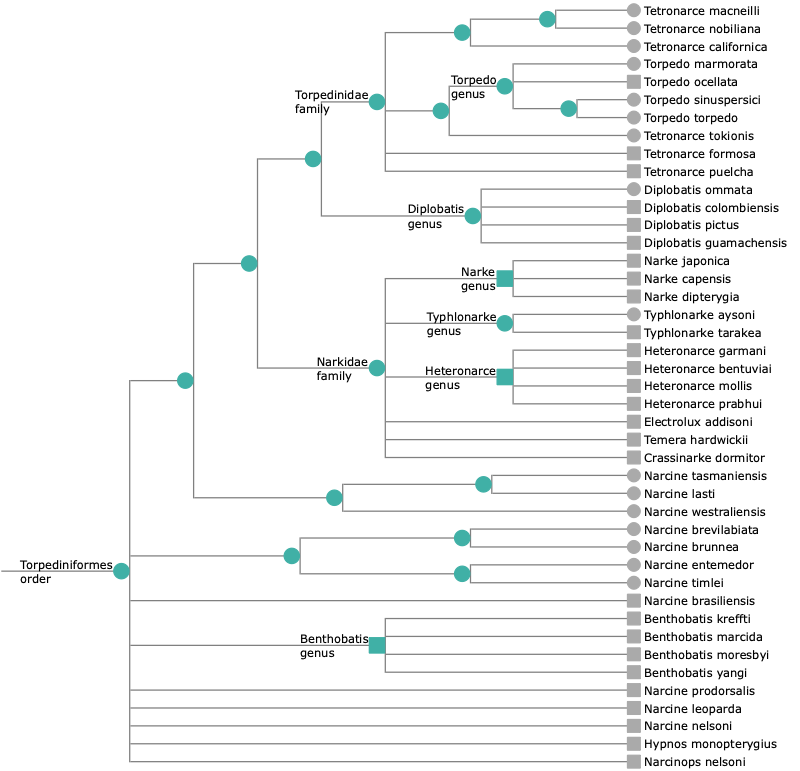

In [3]:
tree_plotting.plot_undated_tree(tree, inline=True)

The round nodes are nodes with phylogenetic backing, while square nodes have been added by the synthesis algorithm from the taxonomy. The tree has no branch length information; in these visualisations the branches are simply scaled to line up the leaves on the right.

You will notice a lot of polytomies in the tree. Look closely and you will see that the round nodes - representing the phylogenetic backbone - form a bifurcating tree (other than one monotypic family and one monotypic genus). The polytomies exist where taxonomy has been attached into the backbone. The first task in this workflow is to resolve these polytomies. 

## 3. Polytomy resolution

### 3.a. Polytomies that originated from joining phylogeny and taxonomy

This has two stages. The first stage is to resolve groups of species of the same genus. For example, in the case of the _Torpedo_ genus, three species have phylogenetic information while one (_T. ocellata_) has been added from taxonomy: it has been connected directly to the genus node, forming a polytomy. We resolve this case by detaching _T. ocellata_ and randomly choosing one of the other branches in the genus to insert the species into (or, it could be made sister to the whole group).

Another case is the genus _Narcine_. In the phylogenetic backbone (round nodes), the genus is paraphyletic. This precludes the synthesis algorithm from naming a single node that represents the genus. Species added from the taxonomy (square nodes, e.g. _N. prodorsalis_) have therefore been connected to the common ancestor of the _Narcine_ groups in the backbone, forming a polytomy at that node. To resolve these cases, we detach the species-from-taxonomy (square nodes) and insert them into a randomly selected branch across all _Narcine_ groups in the backbone.

The second stage is to collect up all remaining groups (groups of higher taxonomic rank, and species that have no representation in the backbone) that have been added from the taxonomy to form a polytomy (e.g. the _Benthobatis_ genus). For each of these, a relevant section of backbone is found into which the group can be inserted while respecting the taxonomic hierarchy with and no phylogeny-supported congeneric groups interrupted.

Let's illustrate these two stages. First, we run some 'labelling' steps that collect up the various polytomies and backbones, but don't yet change the tree.

In [4]:
genus_dict = {}       # nodes below genus nodes
nmp_genus_dict = {}   # non-monophyletic genera
tree_labelling.populate_genus_dict(tree, genus_dict, nmp_genus_dict, None)

tofix_dict = {}       # all other nodes from attached from taxonomy
tree_labelling.populate_tofix_dict(tree, tofix_dict, nmp_genus_dict)

We will first resolve polytomies within monophyletic genera.

In [5]:
tree_fixing.fix_polyphyly(genus_dict, rng)

Let's see how the tree looks after this first step. The bold species are the species moved, and the red-coloured nodes are new nodes inserted to resolve the polytomies.

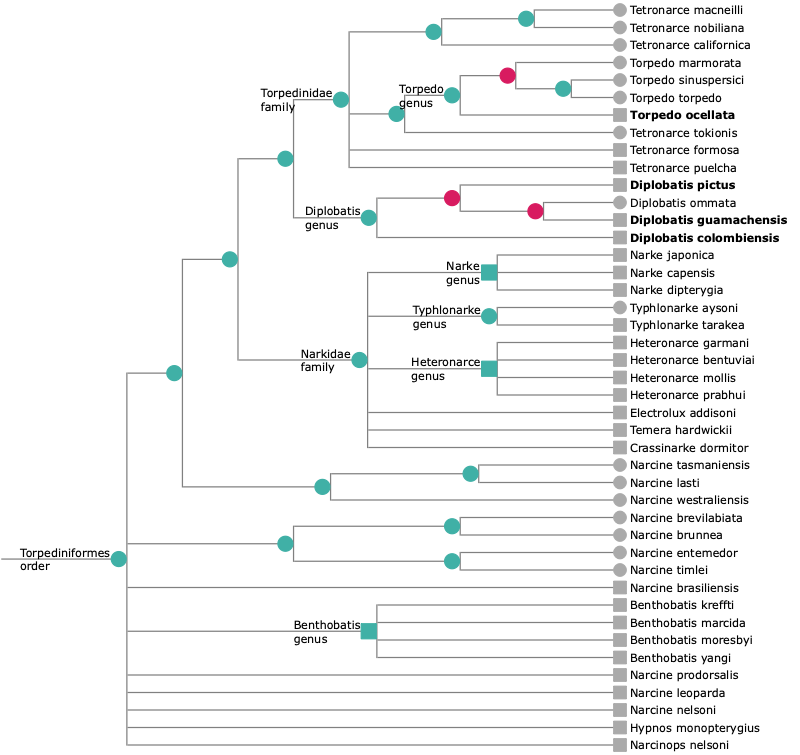

In [6]:
to_highlight = [node.name for key in genus_dict for node in genus_dict[key][0]]

tree_plotting.plot_undated_tree(tree, inline=True, to_highlight=to_highlight)

Next, the non-monophyletic genera.

In [7]:
tree_fixing.fix_polyphyly(nmp_genus_dict, rng)

Let's plot the tree. The previously-inserted nodes are now yellowish, and the nodes inserted in this step are red.

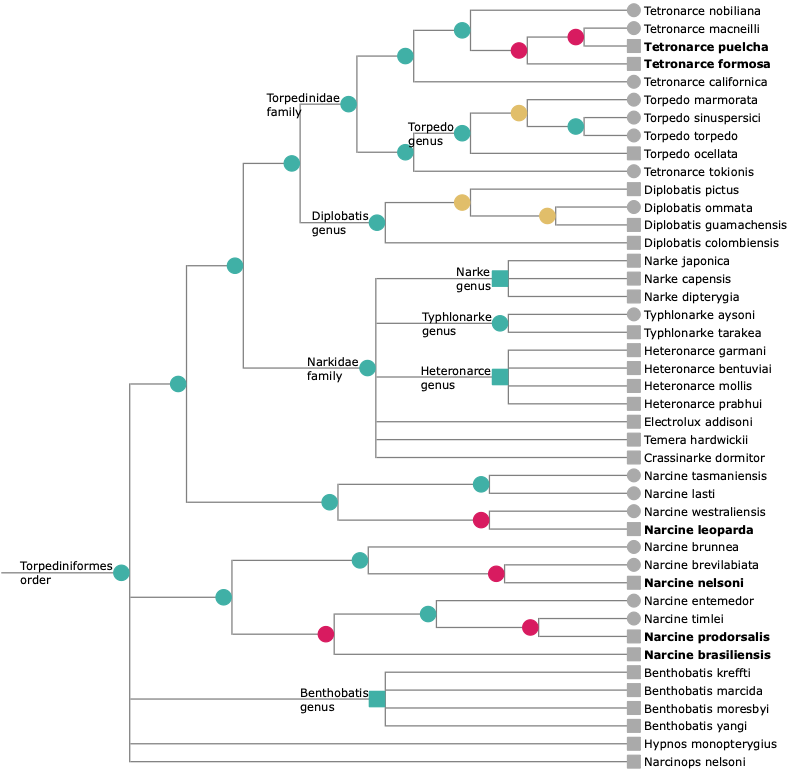

In [8]:
to_highlight = [node.name for key in nmp_genus_dict for node in nmp_genus_dict[key][0]]
tree_plotting.plot_undated_tree(tree, inline=True, to_highlight=to_highlight)

And now, we resolve the polytomies where groups of higher rank or single species have been added to the backbone.

In [9]:
tree_labelling.populate_tofix_bkb(tree, tofix_dict, [])
fix_dict = tree_labelling.process_tofix_bkb(tofix_dict)

tree_fixing.fix_polyphyly(fix_dict, rng, expand_parent_backbones=True)

The tree now looks like this. The _Benthobatis_ genus was previously attached to the crown Torpediniformes order node. This could have been placed anywhere in the backbone that was not within either an existing genus or a group of species of a single genus (that is, the groups we resolved in the first stage of this process). The taxonomy-originated groups in the Narkidae family (e.g. _Narke_) could be placed only within the family.

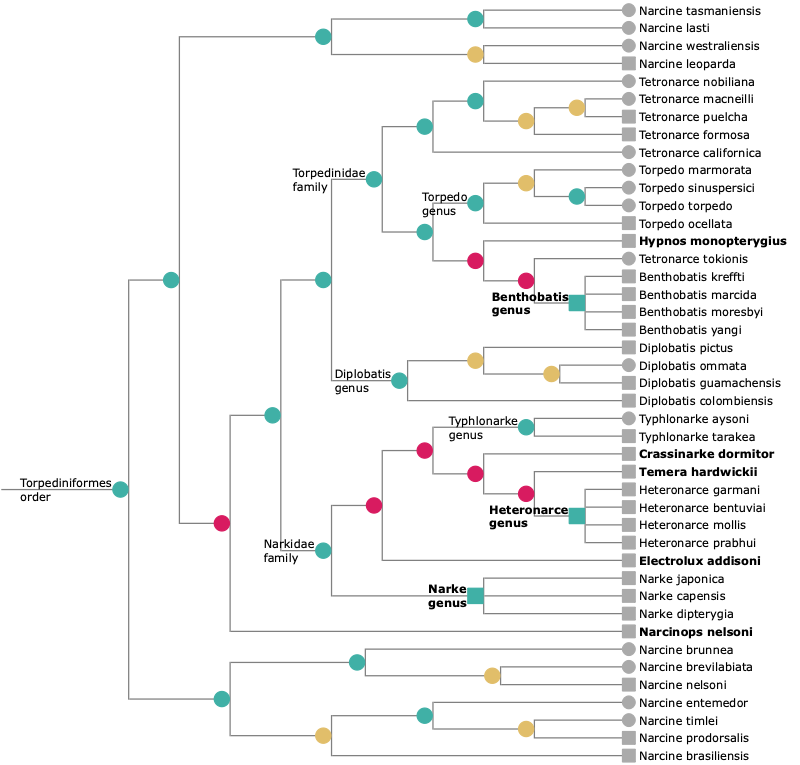

In [10]:
to_highlight = [node.name for key in fix_dict for node in fix_dict[key][0]]
tree_plotting.plot_undated_tree(tree, inline=True, to_highlight=to_highlight)

### 3.b. Polytomies within taxonomy

At this point, the remaining polytomies are within groups that came only from taxonomy. These are resolved by choosing a topology at random.

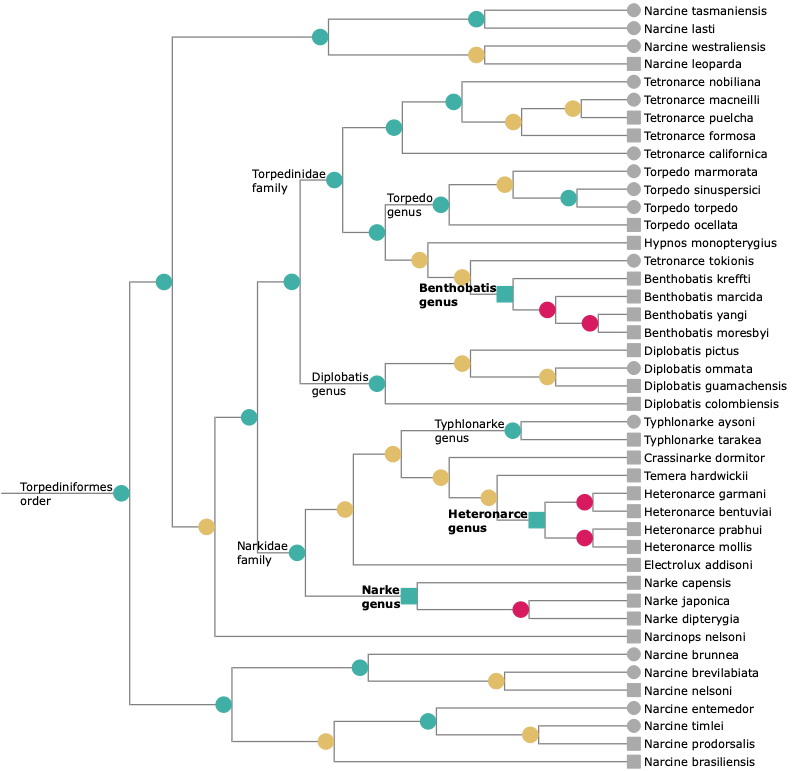

In [11]:
to_highlight = [node.name for node in tree.traverse() if len(node.children) > 2]

tree_fixing.fix_all_polytomies(tree, rng)

tree_plotting.plot_undated_tree(tree, inline=True, to_highlight=to_highlight)

We now have a fully-resolved tree, with taxonomic hierarchy respected and no phylogeny-supported congeneric groups interrupted. The final step is to date the tree.

## 4. Dating the tree

The first stage of dating the tree is to assign the available dates to nodes in our tree. The dates are extracted from the underlying Open Tree database of trees. The package `chronosynth` searches through the database for time-scaled trees and finds the correpsonding common ancestors in the Open Tree supertree. The dates we will use here are cached in the included file `chronosynth_date_info/node_ages.json`. We already loaded them when we loaded the metadata at the beginning. Now let's assign them to the tree.

In [12]:
tree_dating.assign_dates(tree, dates)

Let's look at the dates - these are in Mya. Note that we must have a date on the root node for the interpolation algorithms to work. Leaf nodes without a date are assumed to have a date of 0.

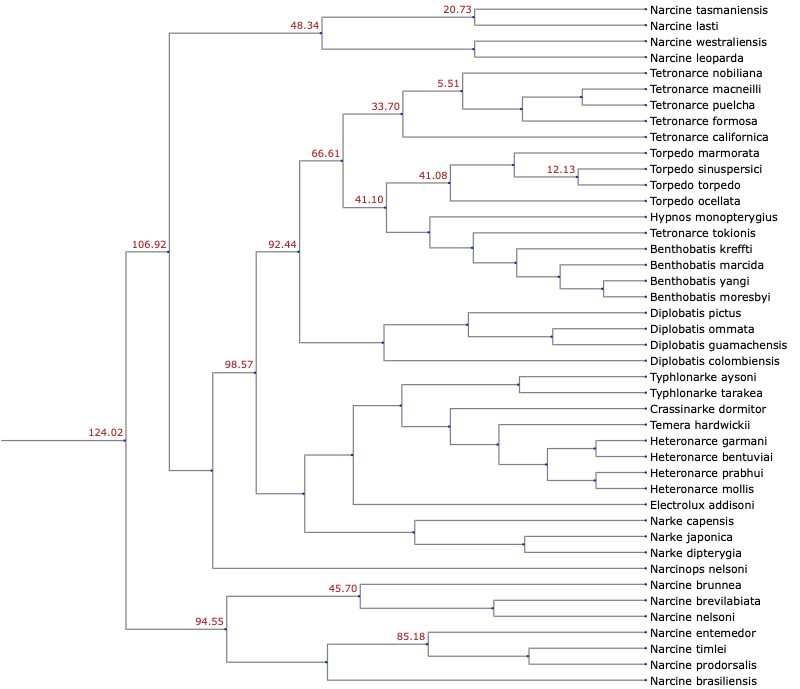

In [13]:
tree_plotting.plot_dated_tree(tree, inline=True)

Now we can interpolate a date on each of the undated internal nodes to produce a fully dated tree. We will use here the EQS-LS algorithm.

In [14]:
tree_copy = tree.copy()
tree_dating.date_labelling(tree)
tree_dating.impute_missing_dates(tree, l=0.25)
tree_dating.compute_branch_lengths(tree)

And now we have our tree! We can draw a chronogram, with branches drawn in proportion to time.

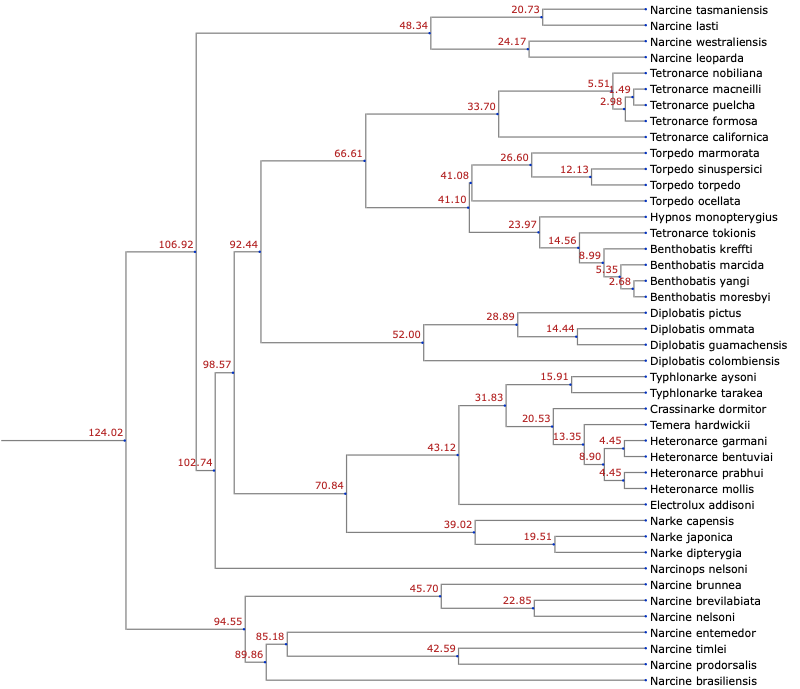

In [15]:
tree_plotting.plot_dated_tree(tree, inline=True, true_branch_lengths=True)

To illustrate a different interpolation algorithm, we will now remove the interpolated dates, and instead interpolate using a birth-model algorithm.

In [16]:
tree = tree_copy.copy()
tree_dating.date_labelling(tree)
tree_dating.impute_missing_dates(tree, use_birth_model=True, rng=rng)
tree_dating.compute_branch_lengths(tree)

This gives slightly different results, particulary noticeable for example in the _Heteronarce_ genus.

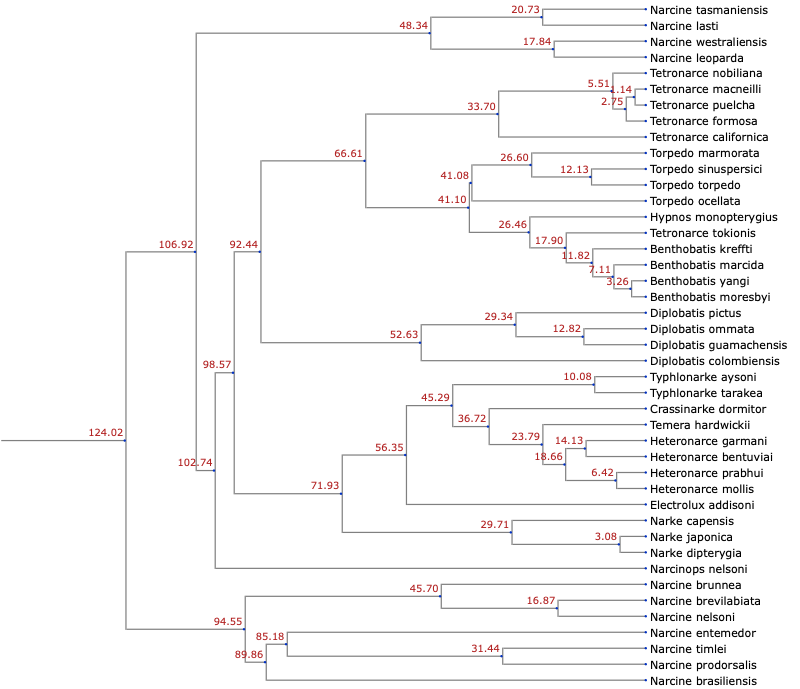

In [17]:
tree_plotting.plot_dated_tree(tree, inline=True, true_branch_lengths=True)

And finally, we can write our resolved, time-scaled tree to a Newick file.

In [18]:
tree_dating.write_tree_with_branch_lengths(tree, "examples/my_dated_tree.tre")

Note that the polytomy resolution steps and the birth model interpolation algorithm are stochastic. Consecutive runs or a different seed for the random number generator will produce different topologies and different dates.

## 5. Appendix

Here we give the code to extract the subtree we used here. We require the data from the Open Tree of Life; here we assume the tree and annotations are in the folder `opentree16.1_tree` and the Open Tree Taxonomy is in the folder `ott3.7.3`. We will also use the list of species we want to include here.

In [ ]:
from dated_complete_tree import tree_loading
from dated_complete_tree import tree_labelling
from dated_complete_tree import tree_fixing
from dated_complete_tree import tree_dating

rng = np.random.default_rng(seed=1)

dates, phylogeny_nodes, taxa = tree_loading.load_metadata(date_cache="chronosynth_date_info/node_ages.json",
                                                          annotations="opentree16.1_tree/annotations.json",
                                                          taxonomy="ott3.7.3/taxonomy.tsv",
                                                          force_dates_refresh=False)

tree = tree_loading.build_and_annotate_tree(phylogeny_nodes,
                                            taxa,
                                            tree_filename="opentree16.1_tree/labelled_supertree/labelled_supertree_ottnames.tre",
                                            suppress_logging=True)

tree_labelling.add_anc_ranks(tree)
tree_labelling.add_desc_ranks(tree)

for subtree in  tree.search_nodes(name="Torpediniformes_ott356640"):
    break

with open('examples/Torpediniformes_species_to_include.txt', 'r') as fin:
    tips = [line.strip() for line in fin.readlines()]

subtree.prune(tips)

subtree.write('examples/my_new_Torpediniformes.tre', parser=1, format_root_node=True)